In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

# Global plotting style (consistent across all figures)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10


In [ ]:
# 1.1 Load data

train_df = pd.read_csv("fbref_data_nov_26.csv")  # 12 games
test_df  = pd.read_csv("fbref_data_dec_1.csv")   # 13 games

train_df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'fbref_data_nov_26.csv'

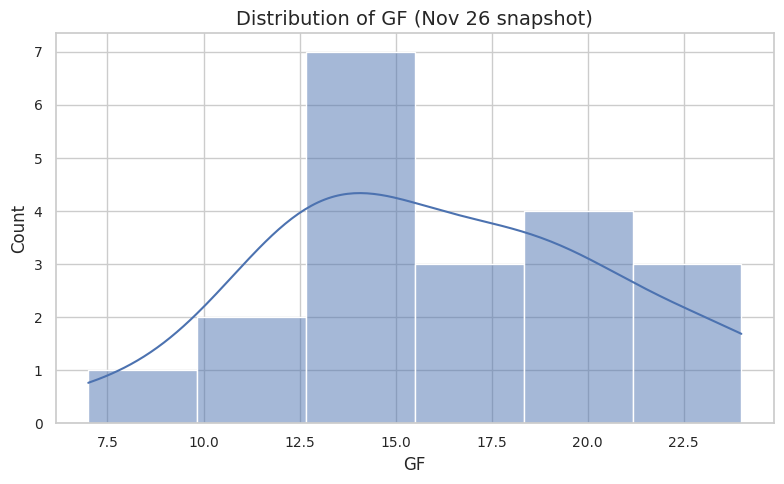

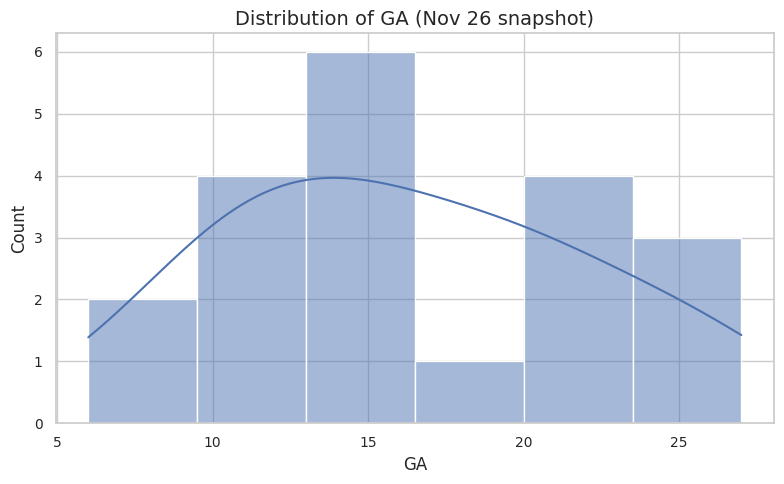

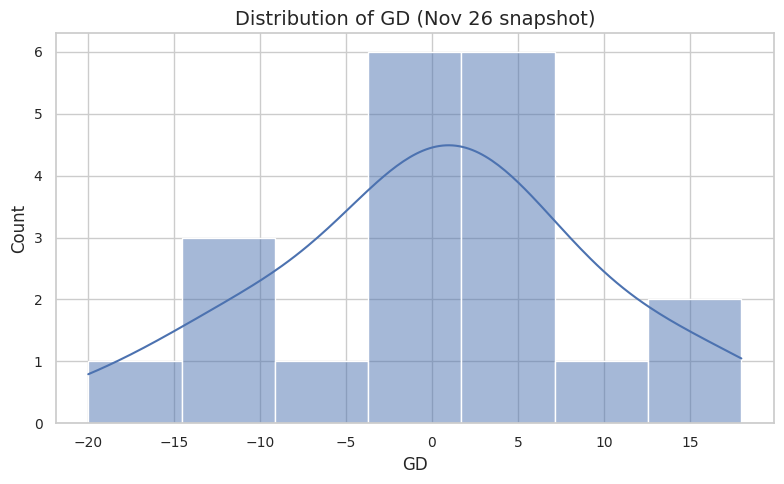

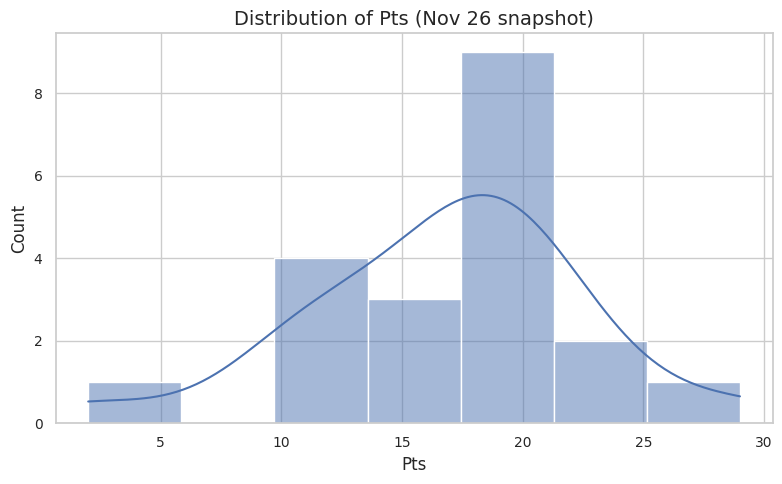

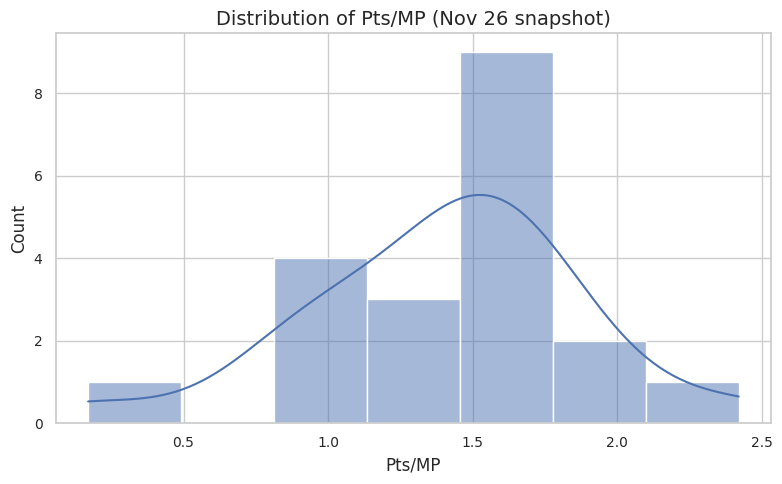

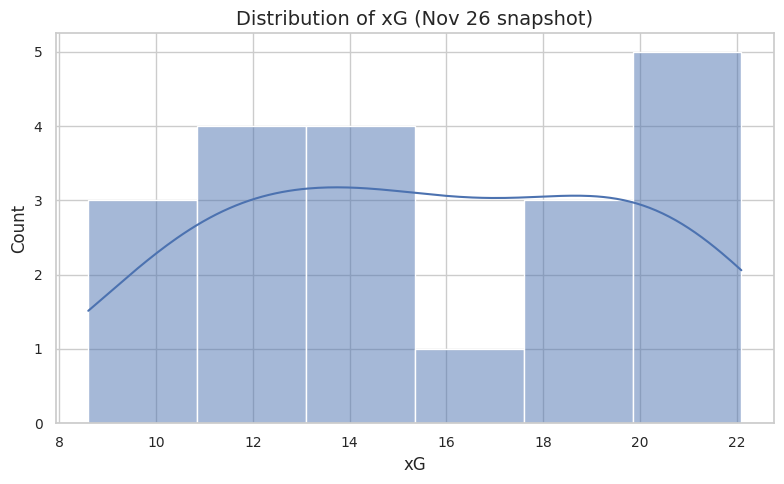

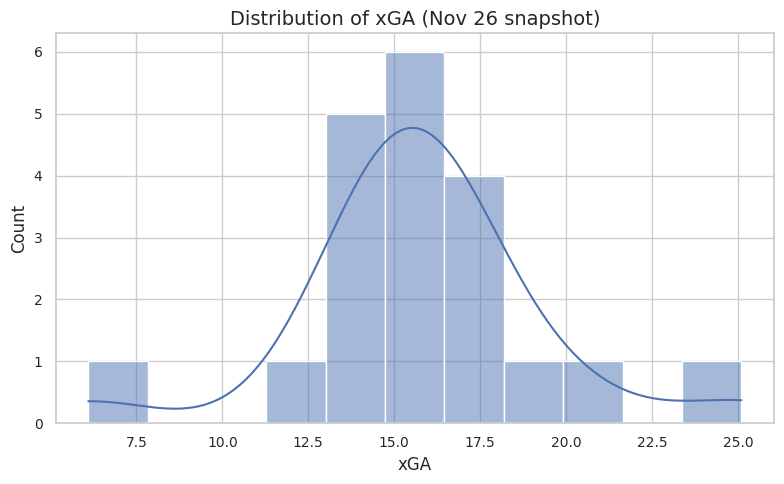

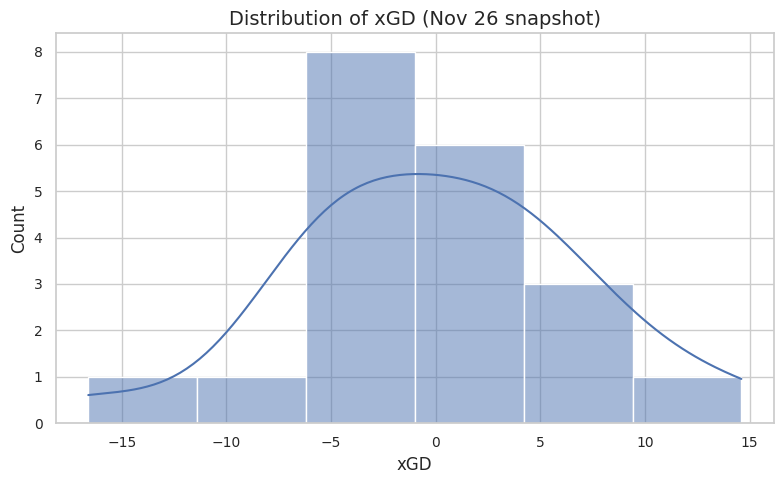

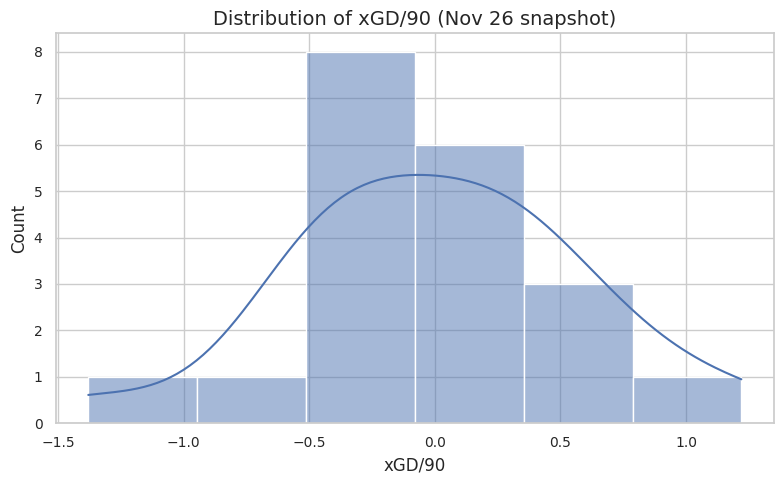

In [ ]:
# 2.1 Distributions of key stats

num_cols = ["GF", "GA", "GD", "Pts", "Pts/MP", "xG", "xGA", "xGD", "xGD/90"]

for col in num_cols:
    plt.figure()
    sns.histplot(train_df[col], kde=True)
    plt.title(f"Distribution of {col} (Nov 26 snapshot)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


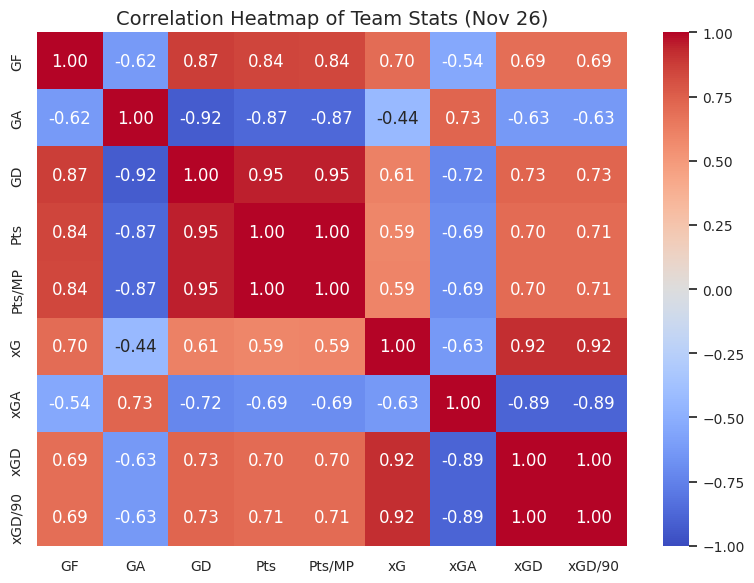

In [ ]:
# 2.2 Correlation heatmap

corr = train_df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Team Stats (Nov 26)")
plt.tight_layout()
plt.show()


In [ ]:
# 3.1 Train Random Forest regressor

features = ["GF", "GD", "Pts/MP", "xG", "xGD", "xGD/90"]

x_train = train_df[features]
y_train = train_df["Pts"]

x_test = test_df[features]
y_test = test_df["Pts"]

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# Proper train/test metrics
print("Train R^2:", model.score(x_train, y_train))
print("Test  R^2:", model.score(x_test, y_test))

mae = mean_absolute_error(y_test, y_pred)
print("Test MAE:", mae)


Train R^2: 0.9729426534339024
Test  R^2: 0.8948537925696595
Test MAE: 1.7179000000000002


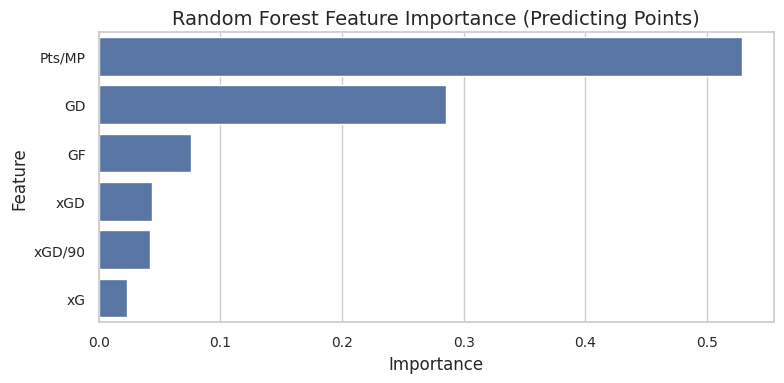

,feature,importance
2,Pts/MP,0.528799
1,GD,0.285361
0,GF,0.075671
4,xGD,0.044131
5,xGD/90,0.042543
3,xG,0.023496


In [ ]:
# 4.1 Feature importance from the Random Forest regressor

importances = model.feature_importances_
fi_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=fi_df, x="importance", y="feature")
plt.title("Random Forest Feature Importance (Predicting Points)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

fi_df


In [ ]:
# 4.2 Binary label: Top-4 vs Not Top-4, using Rk column

train_cls = train_df.copy()
train_cls["Top4"] = (train_cls["Rk"] <= 4).astype(int)

X_cls = train_cls[features]
y_cls = train_cls["Top4"]

X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(
    X_cls, y_cls, test_size=0.3, random_state=42, stratify=y_cls
)

clf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

clf.fit(X_train_cls, y_train_cls)

print("Train accuracy:", clf.score(X_train_cls, y_train_cls))
print("Val   accuracy:", clf.score(X_val_cls, y_val_cls))


Train accuracy: 1.0
Val   accuracy: 1.0


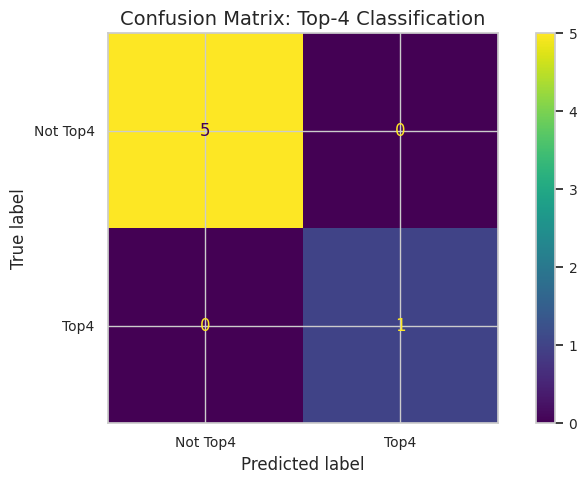

In [ ]:
# 4.3 Confusion matrix

y_val_pred = clf.predict(X_val_cls)
cm = confusion_matrix(y_val_cls, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Top4", "Top4"])
disp.plot()
plt.title("Confusion Matrix: Top-4 Classification")
plt.tight_layout()
plt.show()


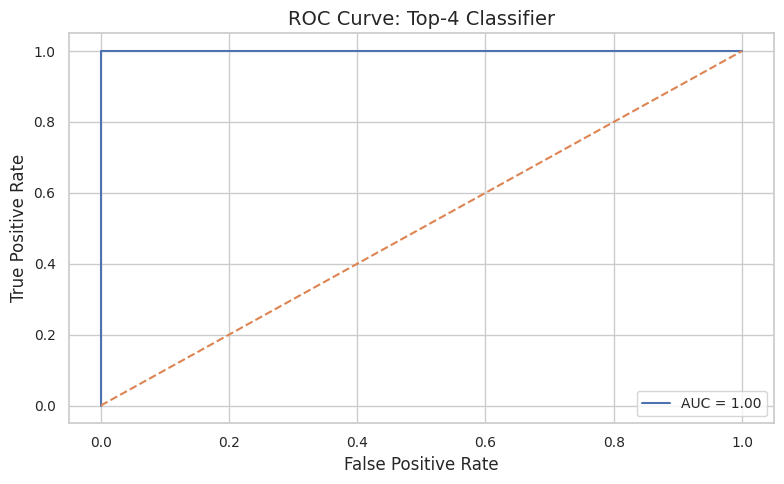

In [ ]:
# 4.4 ROC curve

y_val_proba = clf.predict_proba(X_val_cls)[:, 1]  # probability of being Top-4

fpr, tpr, thresholds = roc_curve(y_val_cls, y_val_proba)
auc = roc_auc_score(y_val_cls, y_val_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Top-4 Classifier")
plt.legend()
plt.tight_layout()
plt.show()


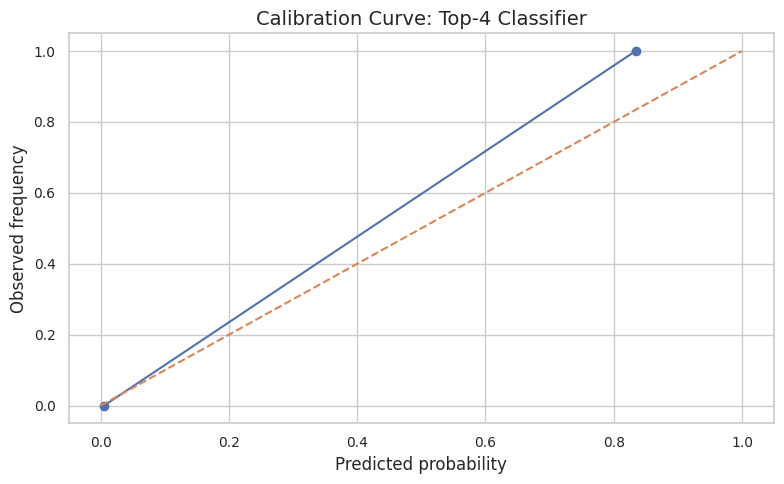

In [ ]:
# 4.5 Calibration curve

prob_true, prob_pred = calibration_curve(y_val_cls, y_val_proba, n_bins=5)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve: Top-4 Classifier")
plt.tight_layout()
plt.show()


In [ ]:
# 5.1 Retrain model on Dec 1 data (13 matches) and predict points

# Use Dec 1 data as "current state"
X_current = test_df[features]
y_current = test_df["Pts"]

model.fit(X_current, y_current)

def show_predicted_rankings():
    teams = test_df["Squad"]
    predicted_points = model.predict(X_current)

    results = pd.DataFrame({
        "Team": teams,
        "Predicted_Points": predicted_points
    })

    # Rank by predicted points (higher is better)
    results["Predicted_Rank"] = results["Predicted_Points"].rank(ascending=False).astype(int)

    results = results.sort_values("Predicted_Rank")
    return results

projected_table = show_predicted_rankings()
projected_table


,Team,Predicted_Points,Predicted_Rank
0,Arsenal,27.946,1
1,Manchester City,24.938,2
2,Chelsea,24.230,3
3,Aston Villa,22.562,4
4,Brighton,21.860,5
5,Sunderland,21.510,6
6,Manchester Utd,21.102,7
7,Liverpool,21.086,8
8,Crystal Palace,19.946,9
9,Brentford,19.250,10


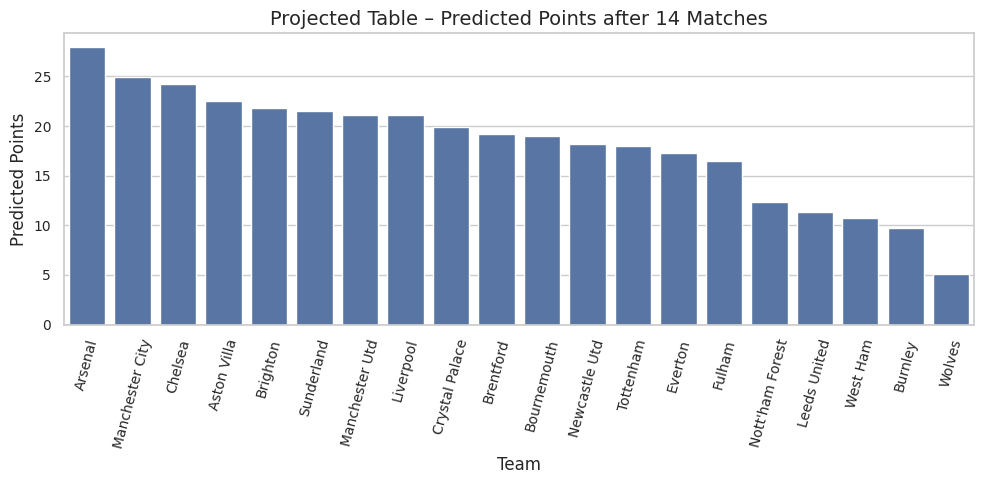

In [ ]:
# 5.2 Bar plot of predicted points

plt.figure(figsize=(10, 5))
sns.barplot(data=projected_table, x="Team", y="Predicted_Points")
plt.xticks(rotation=75)
plt.ylabel("Predicted Points")
plt.title("Projected Table – Predicted Points after 14 Matches")
plt.tight_layout()
plt.show()


In [ ]:
# 6.1 Rating based on xGD/90

ratings = test_df.set_index("Squad")["xGD/90"]

def logistic(x):
    return 1 / (1 + np.exp(-x))

home_advantage = 0.25  # tweakable

def match_probabilities(home_team, away_team):
    r_home = ratings[home_team]
    r_away = ratings[away_team]

    diff = (r_home - r_away) + home_advantage

    p_home = logistic(diff)
    p_away = logistic(-diff)
    p_draw = max(0.0, 1.0 - p_home - p_away)

    return p_home, p_draw, p_away


In [ ]:
# 6.2 Example fixtures and probabilities
# Replace these with actual fixtures you care about

fixtures = pd.DataFrame({
    "Home": ["Arsenal", "Chelsea"],
    "Away": ["Manchester City", "Liverpool"]
})

prob_rows = []
for _, row in fixtures.iterrows():
    p_home, p_draw, p_away = match_probabilities(row["Home"], row["Away"])
    prob_rows.append({
        "Home": row["Home"],
        "Away": row["Away"],
        "P_home_win": round(p_home * 100, 1),
        "P_draw": round(p_draw * 100, 1),
        "P_away_win": round(p_away * 100, 1),
    })

fixture_probs = pd.DataFrame(prob_rows)
fixture_probs


,Home,Away,P_home_win,P_draw,P_away_win
0,Arsenal,Manchester City,64.8,0.0,35.2
1,Chelsea,Liverpool,61.5,0.0,38.5
